In [1]:
import torch
 
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

import pandas as pd
#from ctgan import CTGAN

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

True
NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
!ls

CTGAN  GANS  c2			      data		project1
FINs   c1    classAdversarialExample  instructions.txt	tf_env


In [4]:
#this is for other enviorments
# df = pd.read_csv("../data/raw/train_clean.csv")

#for my own enviorment
df = pd.read_csv("./CTGAN/Proyecto2_Deep_Learning-/data/raw/train_clean.csv")

In [ ]:
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

df_good = df[df["Credit_Score"] == "Good"]
df_standard = df[df["Credit_Score"] == "Standard"]
df_poor = df[df["Credit_Score"] == "Poor"]


In [7]:
poor_metadata = SingleTableMetadata()
poor_metadata.detect_from_dataframe(df_poor)
#this is for other enviorments
#poor_metadata.save_to_json("../metadata/v3/poor_metadata.json")  
poor_metadata.save_to_json("./CTGAN/Proyecto2_Deep_Learning-/metadata/v2/poor_metadata.json")  

good_metadata = SingleTableMetadata()
good_metadata.detect_from_dataframe(df_good)
#this is for other enviorments
#good_metadata.save_to_json("../metadata/v3/good_metadata.json")  
good_metadata.save_to_json("./CTGAN/Proyecto2_Deep_Learning-/metadata/v2/good_metadata.json")  

standard_metadata = SingleTableMetadata()
standard_metadata.detect_from_dataframe(df_standard)
#this is for other enviorments
#standard_metadata.save_to_json("../metadata/v3/standard_metadata.json")  
standard_metadata.save_to_json("./CTGAN/Proyecto2_Deep_Learning-/metadata/v2/standard_metadata.json")  

In [19]:
print(metadata)

{
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "Age": {
            "sdtype": "numerical"
        },
        "Occupation": {
            "sdtype": "categorical"
        },
        "Annual_Income": {
            "sdtype": "numerical"
        },
        "Monthly_Inhand_Salary": {
            "sdtype": "numerical"
        },
        "Num_Bank_Accounts": {
            "sdtype": "numerical"
        },
        "Num_Credit_Card": {
            "sdtype": "numerical"
        },
        "Interest_Rate": {
            "sdtype": "numerical"
        },
        "Num_of_Loan": {
            "sdtype": "categorical"
        },
        "Delay_from_due_date": {
            "sdtype": "numerical"
        },
        "Num_of_Delayed_Payment": {
            "sdtype": "numerical"
        },
        "Changed_Credit_Limit": {
            "sdtype": "numerical"
        },
        "Num_Credit_Inquiries": {
            "sdtype": "numerical"
        },
        "Credit_Mix": {
            "

In [4]:
EPOCH_COUNT = 1000

# create model
model_good = CTGANSynthesizer(
    metadata,
    epochs=EPOCH_COUNT,
    cuda=True,
    verbose=True
)

model_poor = CTGANSynthesizer(
    metadata,
    epochs=EPOCH_COUNT,
    cuda=True,
    verbose=True
)

# esto es para ver por curiosidad que pasa si creo datos completamente synteticos con la
#ctgan
model_standard = CTGANSynthesizer(
    metadata,
    epochs=EPOCH_COUNT,
    cuda=True,
    verbose=True
)

/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [5]:
model_good.fit(df_good)
model_poor.fit(df_poor)
model_standard.fit(df_standard)

Gen. (-01.54) | Discrim. (-00.16): 100%|████████████████████████████████████████████| 1000/1000 [22:45<00:00,  1.37s/it]
Gen. (+00.96) | Discrim. (+00.19): 100%|████████████████████████████████████████████| 1000/1000 [38:23<00:00,  2.30s/it]
Gen. (-00.05) | Discrim. (-00.46): 100%|██████████████████████████████████████████| 1000/1000 [1:10:54<00:00,  4.25s/it]


In [6]:
target_size = len(df_standard)

n_good_needed = target_size - len(df_good)
n_poor_needed = target_size - len(df_poor)

print(n_good_needed, n_poor_needed)

32679 21886


In [7]:
synthetic_good = model_good.sample(n_good_needed)
synthetic_poor = model_poor.sample(n_poor_needed)

In [8]:
df_balanced = pd.concat([
    df,
    synthetic_good
    ,synthetic_poor
])

print(df_balanced["Credit_Score"].value_counts())

Credit_Score
Good        48253
Standard    48253
Poor        48253
Name: count, dtype: int64


# ------------------
## export data in to 2 csvs
# ------------------

### create balanced data set with original data (basically: REAL + SYNTHETIC)


In [9]:
df_balanced = pd.concat([
    df,
    synthetic_good,
    synthetic_poor
])

print("\nBalanced (mixed) distribution:")
print(df_balanced["Credit_Score"].value_counts())




Balanced (mixed) distribution:
Credit_Score
Good        48253
Standard    48253
Poor        48253
Name: count, dtype: int64


In [ ]:
df_balanced.to_csv("../data/processed/train_balanced_mixed.csv", index=False)

### Synthetic balanced dataset

In [ ]:
TARGET_PER_CLASS = 30000

# Generate synthetic for each class
synthetic_good_sampled = model_good.sample(TARGET_PER_CLASS)
synthetic_poor_sampled = model_poor.sample(TARGET_PER_CLASS)
synthetic_standard_sampled = model_standard.sample(TARGET_PER_CLASS)

# Combine all synthetic data
df_synthetic_balanced = pd.concat([
    synthetic_good_sampled,
    synthetic_standard_sampled,
    synthetic_poor_sampled
])

print(df_synthetic_balanced["Credit_Score"].value_counts())

# Save
df_synthetic_balanced.to_csv("../data/processed/train_balanced_synthetic2.csv", index=False)

Credit_Score
Good        30000
Standard    30000
Poor        30000
Name: count, dtype: int64


# --------------------------------
## verify how it looks
# --------------------------------

In [12]:
from sdv.evaluation.single_table import evaluate_quality

quality_report_synthetic_good = evaluate_quality(
    real_data=df_good,
    synthetic_data=synthetic_good,
    metadata=metadata
)
print("--"*50)
quality_report_synthetic_poor = evaluate_quality(
    real_data=df_poor,
    synthetic_data=synthetic_poor,
    metadata=metadata
)
print("--"*50)
quality_report_synthetic_standard = evaluate_quality(
    real_data=df_standard,
    synthetic_data=synthetic_standard_sampled,
    metadata=metadata
)
print("--"*50)


Generating report ...

(1/2) Evaluating Column Shapes: |█████████████████████████████████████████████████████| 32/32 [00:00<00:00, 179.33it/s]|
Column Shapes Score: 92.13%

(2/2) Evaluating Column Pair Trends: |██████████████████████████████████████████████| 496/496 [00:01<00:00, 305.28it/s]|
Column Pair Trends Score: 85.69%

Overall Score (Average): 88.91%

----------------------------------------------------------------------------------------------------
Generating report ...

(1/2) Evaluating Column Shapes: |█████████████████████████████████████████████████████| 32/32 [00:00<00:00, 180.48it/s]|
Column Shapes Score: 92.42%

(2/2) Evaluating Column Pair Trends: |██████████████████████████████████████████████| 496/496 [00:01<00:00, 277.86it/s]|
Column Pair Trends Score: 86.46%

Overall Score (Average): 89.44%

----------------------------------------------------------------------------------------------------
Generating report ...

(1/2) Evaluating Column Shapes: |████████████████████

## further table analysis

In [13]:
import matplotlib.pyplot as plt

columns = [
    "Age","Occupation","Annual_Income","Monthly_Inhand_Salary",
    "Num_Bank_Accounts","Num_Credit_Card","Interest_Rate",
    "Num_of_Loan","Delay_from_due_date","Num_of_Delayed_Payment",
    "Changed_Credit_Limit","Num_Credit_Inquiries","Credit_Mix",
    "Outstanding_Debt","Credit_Utilization_Ratio",
    "Payment_of_Min_Amount","Amount_invested_monthly",
    "Monthly_Balance","Credit_Score","Credit_History_Years",
    "Spending_Level","Payment_Size"
]

def compare_datasets(real, synthetic, columns):
    
    numerical_cols = real[columns].select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = real[columns].select_dtypes(include=['object']).columns

    print("\n==============================")
    print("NUMERICAL COLUMN ANALYSIS")
    print("==============================")

    for col in numerical_cols:
        print(f"\n--- {col} ---")
        
        # Stats
        real_mean = real[col].mean()
        synth_mean = synthetic[col].mean()
        real_std = real[col].std()
        synth_std = synthetic[col].std()

        print(f"Real Mean: {real_mean:.2f} | Synthetic Mean: {synth_mean:.2f}")
        print(f"Real Std:  {real_std:.2f} | Synthetic Std:  {synth_std:.2f}")

        # Plot
        plt.figure()
        plt.hist(real[col].dropna(), bins=50, alpha=0.5, label="Real", density=True)
        plt.hist(synthetic[col].dropna(), bins=50, alpha=0.5, label="Synthetic", density=True)
        plt.legend()
        plt.title(col)
        plt.show()

    print("\n==============================")
    print("CATEGORICAL COLUMN ANALYSIS")
    print("==============================")

    for col in categorical_cols:
        print(f"\n--- {col} ---")

        real_counts = real[col].value_counts(normalize=True)
        synth_counts = synthetic[col].value_counts(normalize=True)

        comparison = pd.DataFrame({
            "Real": real_counts,
            "Synthetic": synth_counts
        }).fillna(0)

        print(comparison)

        # Plot
        comparison.plot(kind='bar')
        plt.title(col)
        plt.show()

## a bunch of tables for df good


NUMERICAL COLUMN ANALYSIS

--- Age ---
Real Mean: 36.38 | Synthetic Mean: 32.85
Real Std:  11.10 | Synthetic Std:  12.12


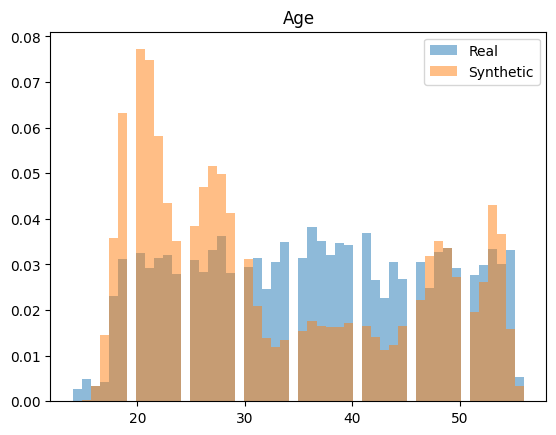


--- Annual_Income ---
Real Mean: 59741.76 | Synthetic Mean: 59977.79
Real Std:  38736.04 | Synthetic Std:  39494.94


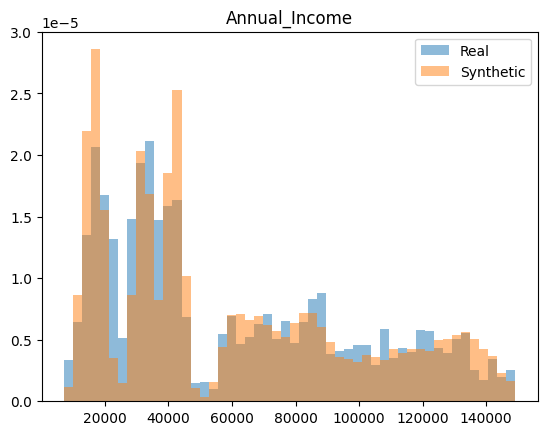


--- Monthly_Inhand_Salary ---
Real Mean: 4949.64 | Synthetic Mean: 4750.35
Real Std:  3217.40 | Synthetic Std:  3156.51


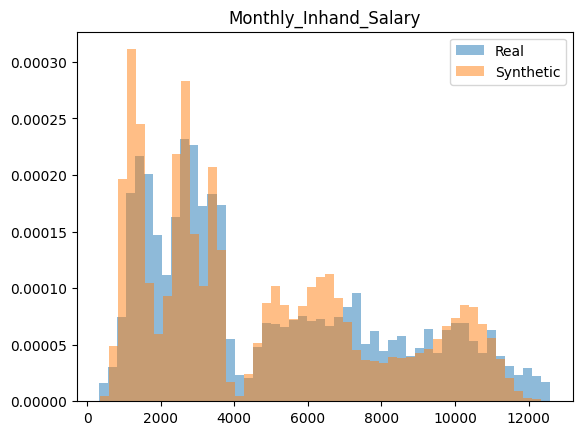


--- Num_Bank_Accounts ---
Real Mean: 3.47 | Synthetic Mean: 3.66
Real Std:  2.23 | Synthetic Std:  2.46


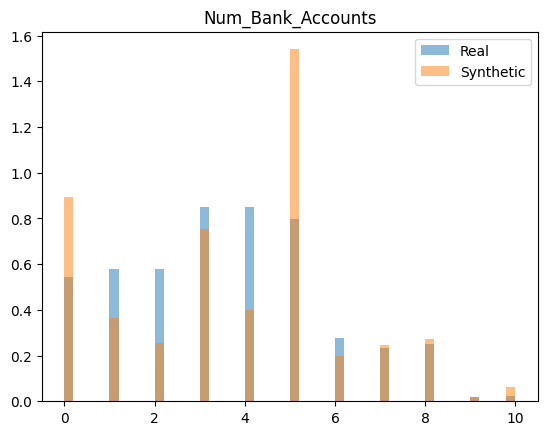


--- Num_Credit_Card ---
Real Mean: 4.15 | Synthetic Mean: 4.09
Real Std:  1.82 | Synthetic Std:  2.11


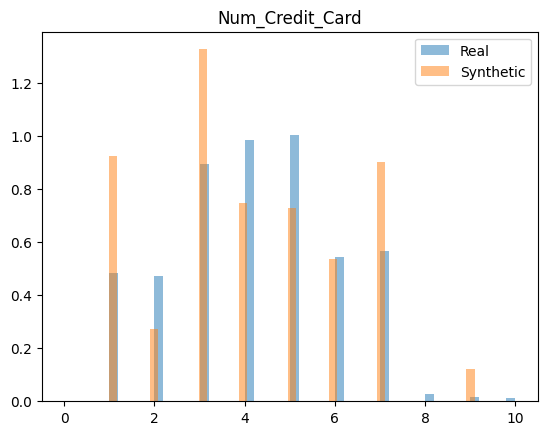


--- Interest_Rate ---
Real Mean: 7.72 | Synthetic Mean: 8.56
Real Std:  4.92 | Synthetic Std:  5.98


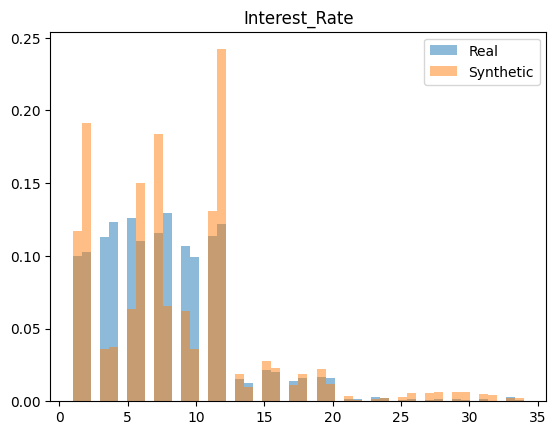


--- Num_of_Loan ---
Real Mean: 2.21 | Synthetic Mean: 2.54
Real Std:  1.66 | Synthetic Std:  1.86


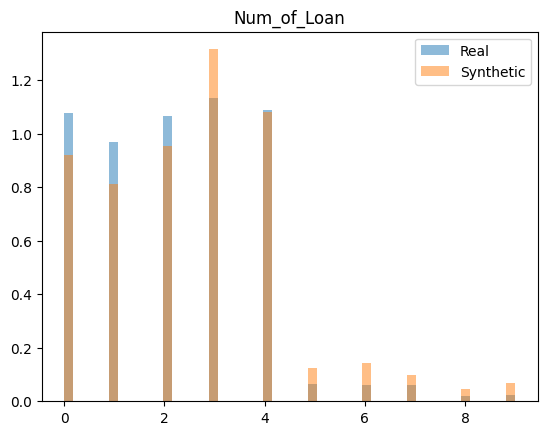


--- Delay_from_due_date ---
Real Mean: 11.12 | Synthetic Mean: 10.76
Real Std:  8.47 | Synthetic Std:  8.90


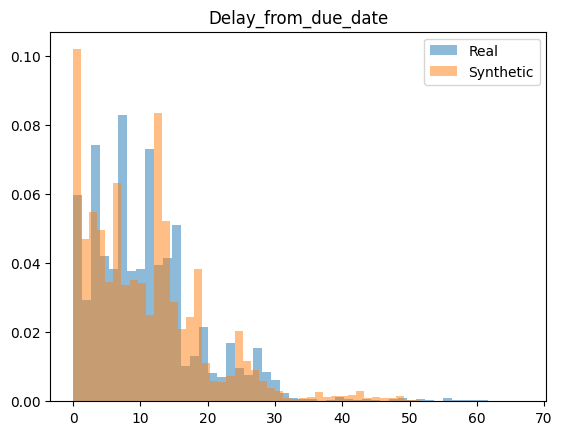


--- Num_of_Delayed_Payment ---
Real Mean: 24.70 | Synthetic Mean: 41.81
Real Std:  212.80 | Synthetic Std:  324.39


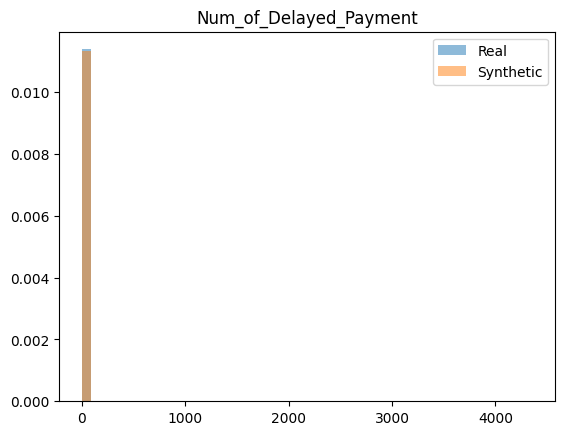


--- Changed_Credit_Limit ---
Real Mean: 7.17 | Synthetic Mean: 6.91
Real Std:  4.56 | Synthetic Std:  5.06


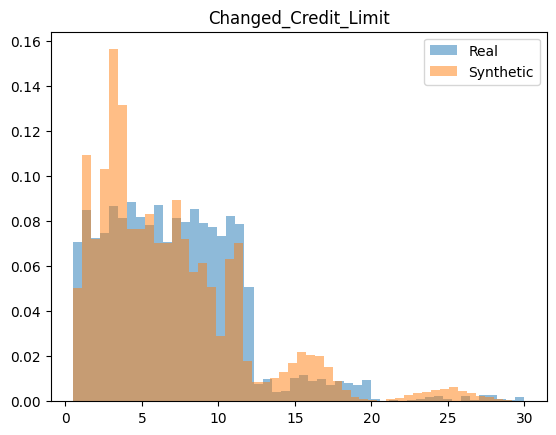


--- Num_Credit_Inquiries ---
Real Mean: 3.18 | Synthetic Mean: 3.80
Real Std:  2.46 | Synthetic Std:  2.47


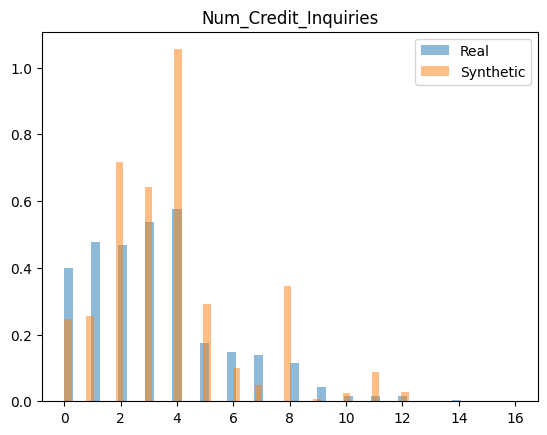


--- Outstanding_Debt ---
Real Mean: 803.55 | Synthetic Mean: 798.69
Real Std:  615.88 | Synthetic Std:  720.75


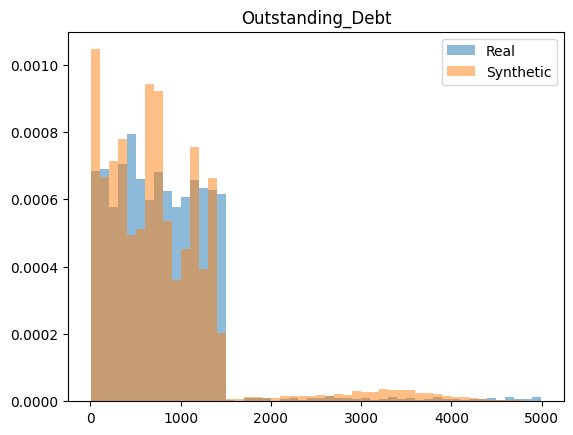


--- Credit_Utilization_Ratio ---
Real Mean: 32.53 | Synthetic Mean: 30.87
Real Std:  5.14 | Synthetic Std:  5.15


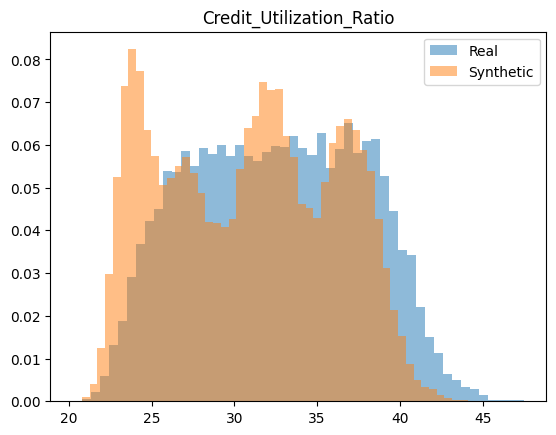


--- Amount_invested_monthly ---
Real Mean: 198.36 | Synthetic Mean: 215.33
Real Std:  134.74 | Synthetic Std:  149.37


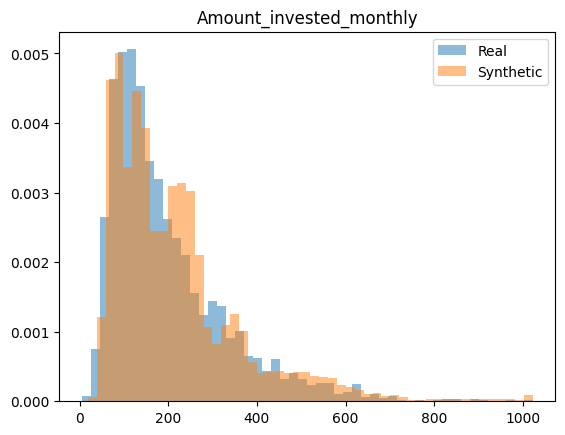


--- Monthly_Balance ---
Real Mean: 456.41 | Synthetic Mean: 445.20
Real Std:  220.21 | Synthetic Std:  209.17


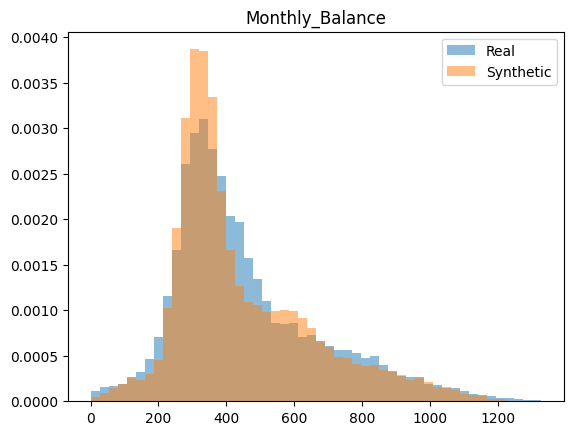


--- Credit_History_Years ---
Real Mean: 23.22 | Synthetic Mean: 22.44
Real Std:  6.15 | Synthetic Std:  6.55


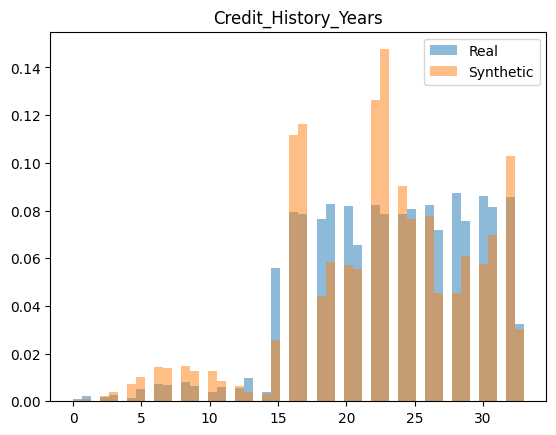


CATEGORICAL COLUMN ANALYSIS

--- Occupation ---
                   Real  Synthetic
Occupation                        
Accountant     0.066328   0.069372
Architect      0.068640   0.086386
Developer      0.066457   0.058723
Doctor         0.066072   0.166590
Engineer       0.070952   0.113070
Entrepreneur   0.064595   0.057407
Journalist     0.070053   0.039261
Lawyer         0.070887   0.039322
Manager        0.069539   0.047462
Mechanic       0.062283   0.058050
Media_Manager  0.071529   0.042994
Musician       0.065558   0.102665
Scientist      0.066007   0.043637
Teacher        0.071144   0.042535
Writer         0.049955   0.032529


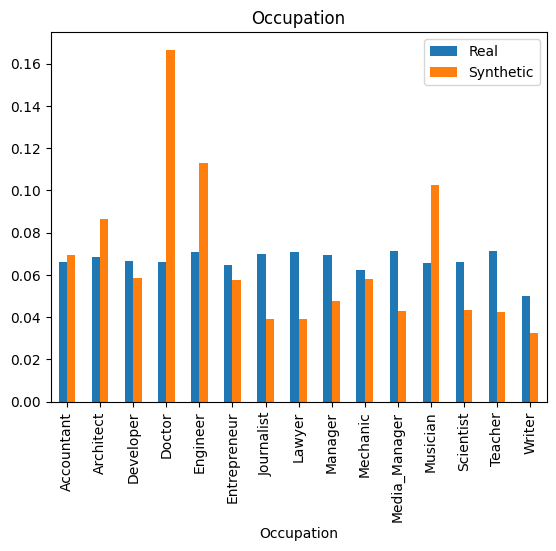


--- Credit_Mix ---
                Real  Synthetic
Credit_Mix                     
Good        0.823552   0.734753
Standard    0.156415   0.213532
Bad         0.020033   0.051715


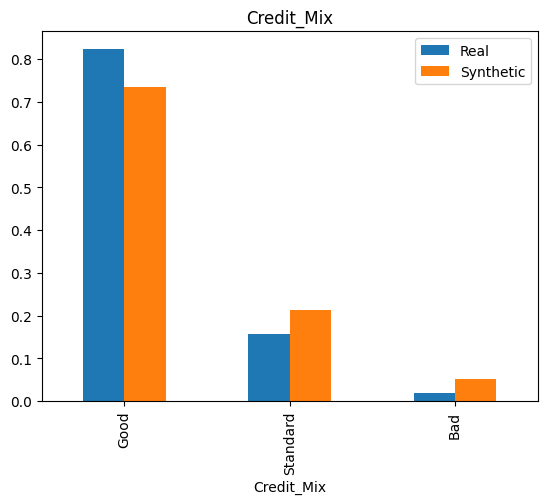


--- Payment_of_Min_Amount ---
                           Real  Synthetic
Payment_of_Min_Amount                     
NM                     0.126557   0.069586
No                     0.760819   0.755500
Yes                    0.112624   0.174914


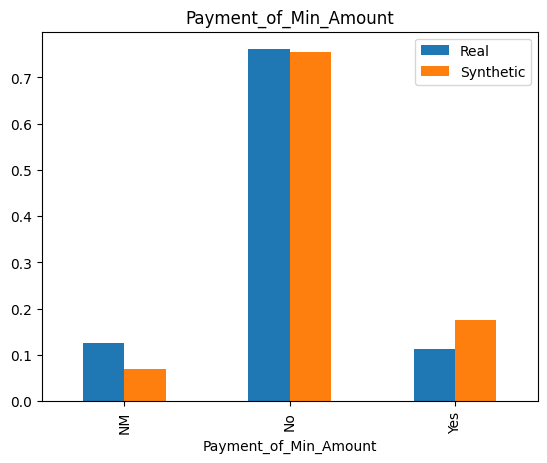


--- Credit_Score ---
              Real  Synthetic
Credit_Score                 
Good           1.0        1.0


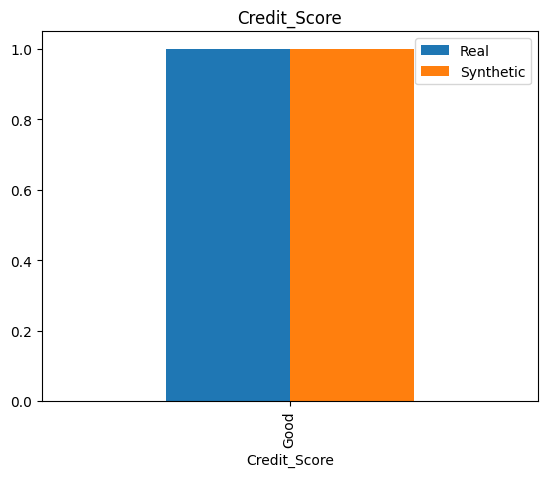


--- Spending_Level ---
                    Real  Synthetic
Spending_Level                     
High            0.490690   0.483063
Low             0.431874   0.406775
Missing         0.077437   0.110162


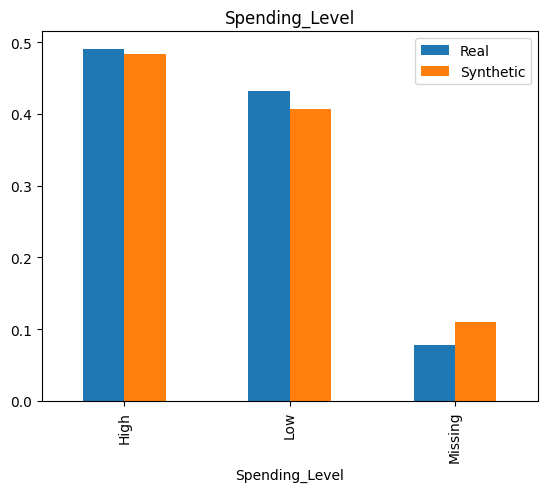


--- Payment_Size ---
                  Real  Synthetic
Payment_Size                     
Large         0.280018   0.381652
Medium        0.335495   0.209217
Missing       0.077437   0.098565
Small         0.307050   0.310566


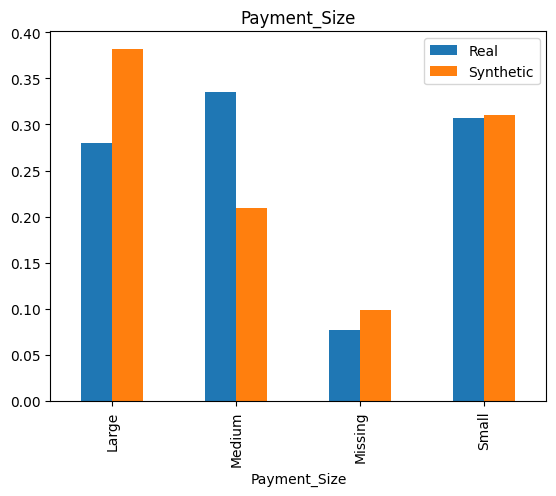

In [14]:
compare_datasets(real=df_good, synthetic=synthetic_good, columns=columns)

## a bunch of tables for df Poor


NUMERICAL COLUMN ANALYSIS

--- Age ---
Real Mean: 31.10 | Synthetic Mean: 28.33
Real Std:  9.96 | Synthetic Std:  10.19


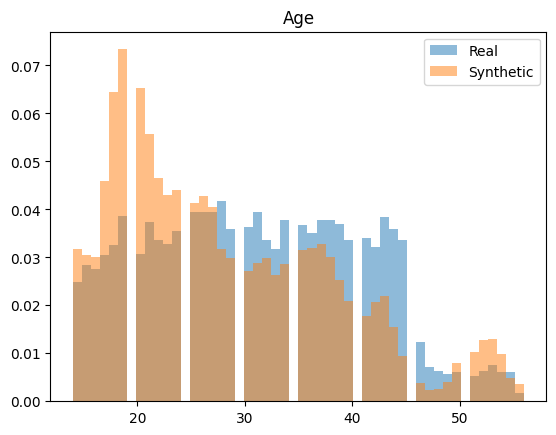


--- Annual_Income ---
Real Mean: 39178.36 | Synthetic Mean: 40022.64
Real Std:  29265.43 | Synthetic Std:  30956.48


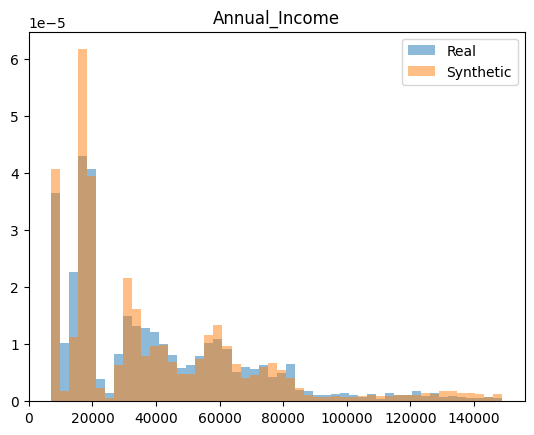


--- Monthly_Inhand_Salary ---
Real Mean: 3263.23 | Synthetic Mean: 3139.82
Real Std:  2440.26 | Synthetic Std:  2342.34


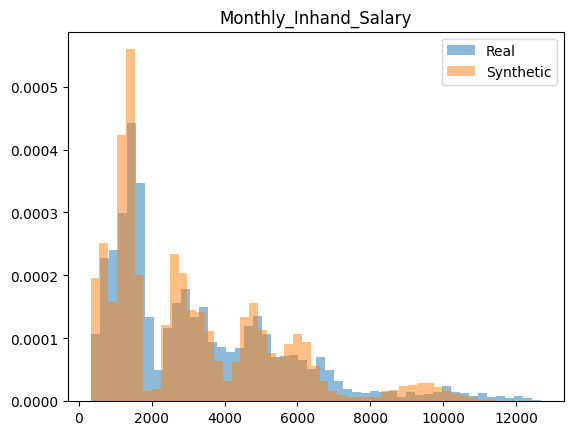


--- Num_Bank_Accounts ---
Real Mean: 6.58 | Synthetic Mean: 6.35
Real Std:  2.48 | Synthetic Std:  2.43


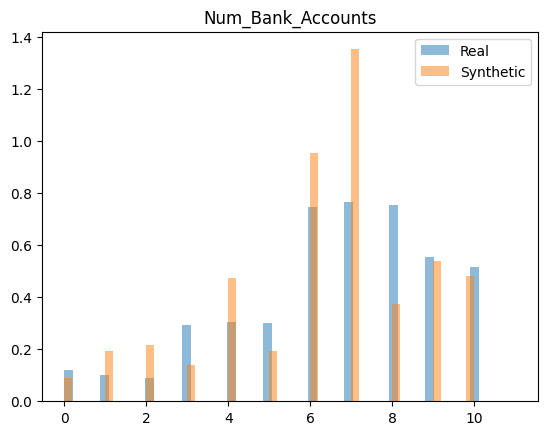


--- Num_Credit_Card ---
Real Mean: 6.64 | Synthetic Mean: 6.29
Real Std:  1.99 | Synthetic Std:  1.93


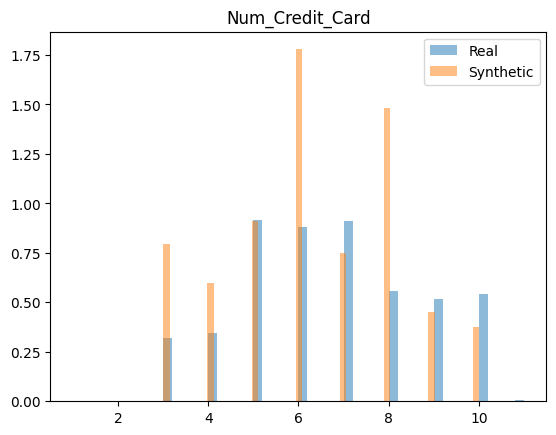


--- Interest_Rate ---
Real Mean: 20.33 | Synthetic Mean: 21.07
Real Std:  8.78 | Synthetic Std:  8.38


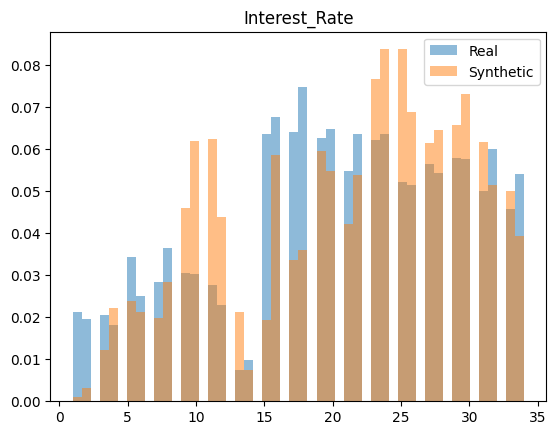


--- Num_of_Loan ---
Real Mean: 4.79 | Synthetic Mean: 4.72
Real Std:  2.43 | Synthetic Std:  2.52


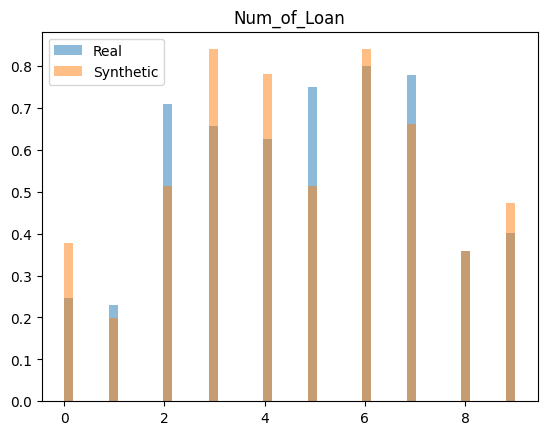


--- Delay_from_due_date ---
Real Mean: 29.92 | Synthetic Mean: 28.67
Real Std:  16.30 | Synthetic Std:  17.28


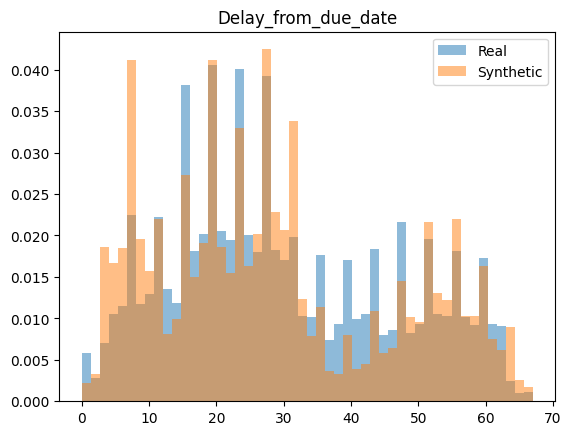


--- Num_of_Delayed_Payment ---
Real Mean: 30.40 | Synthetic Mean: 29.60
Real Std:  206.59 | Synthetic Std:  202.22


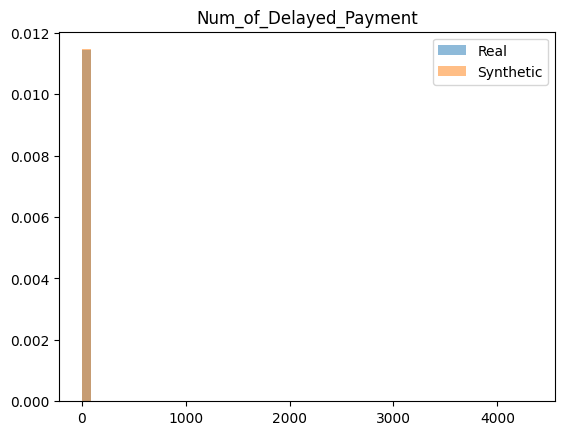


--- Changed_Credit_Limit ---
Real Mean: 11.09 | Synthetic Mean: 11.01
Real Std:  6.89 | Synthetic Std:  7.12


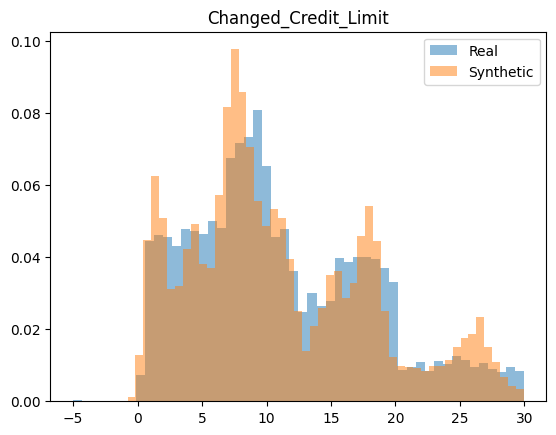


--- Num_Credit_Inquiries ---
Real Mean: 8.14 | Synthetic Mean: 7.58
Real Std:  3.69 | Synthetic Std:  4.36


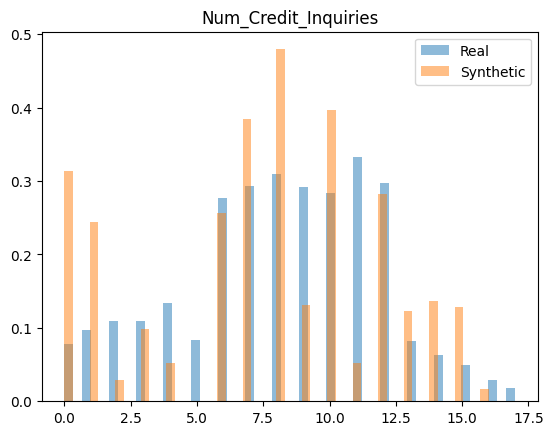


--- Outstanding_Debt ---
Real Mean: 2099.50 | Synthetic Mean: 2020.51
Real Std:  1143.13 | Synthetic Std:  1229.24


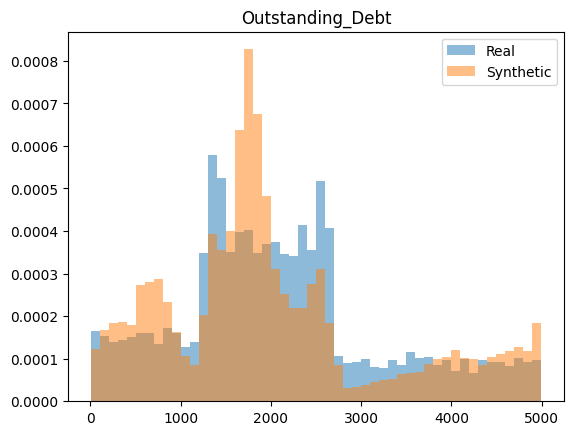


--- Credit_Utilization_Ratio ---
Real Mean: 31.95 | Synthetic Mean: 33.13
Real Std:  5.03 | Synthetic Std:  4.98


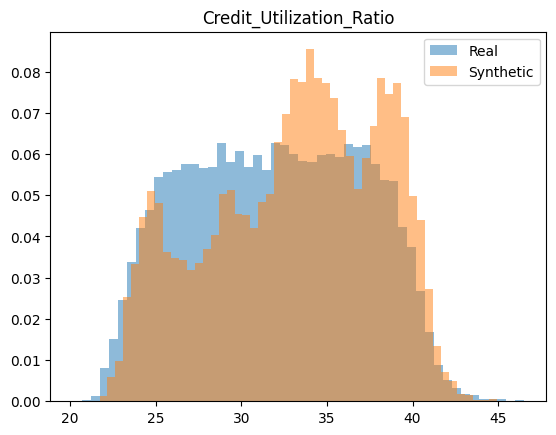


--- Amount_invested_monthly ---
Real Mean: 141.36 | Synthetic Mean: 153.18
Real Std:  97.10 | Synthetic Std:  96.63


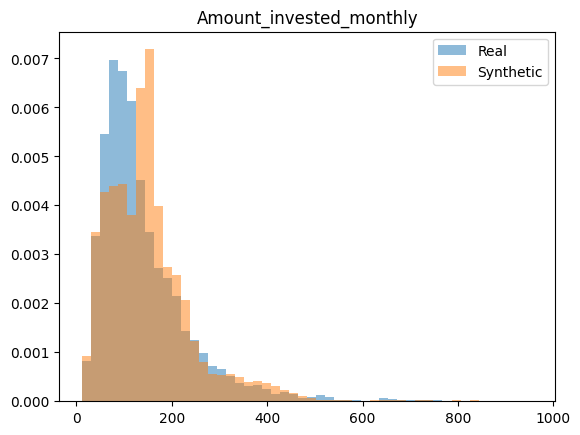


--- Monthly_Balance ---
Real Mean: 338.56 | Synthetic Mean: 387.65
Real Std:  159.96 | Synthetic Std:  205.23


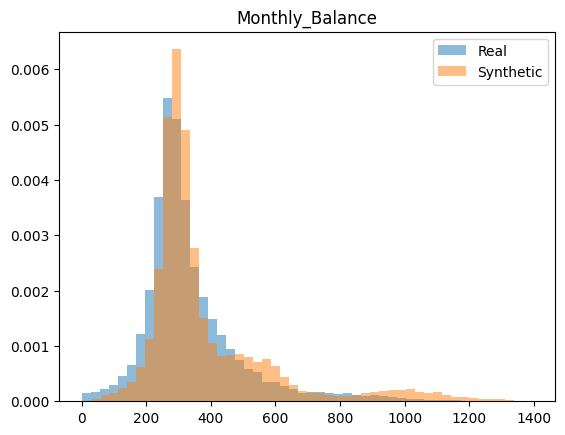


--- Credit_History_Years ---
Real Mean: 13.58 | Synthetic Mean: 12.85
Real Std:  7.24 | Synthetic Std:  7.42


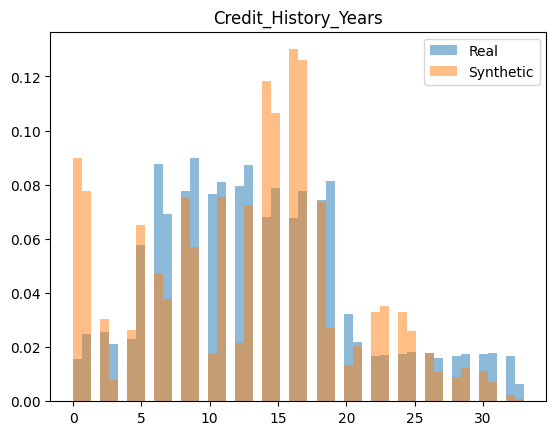


CATEGORICAL COLUMN ANALYSIS

--- Occupation ---
                   Real  Synthetic
Occupation                        
Accountant     0.069822   0.161016
Architect      0.064740   0.078041
Developer      0.067243   0.040711
Doctor         0.061554   0.048433
Engineer       0.071491   0.098236
Entrepreneur   0.070163   0.082153
Journalist     0.063830   0.049255
Lawyer         0.067509   0.064196
Manager        0.062464   0.063557
Mechanic       0.070808   0.088504
Media_Manager  0.061175   0.043270
Musician       0.062123   0.046651
Scientist      0.072174   0.049575
Teacher        0.069139   0.035365
Writer         0.065764   0.051037


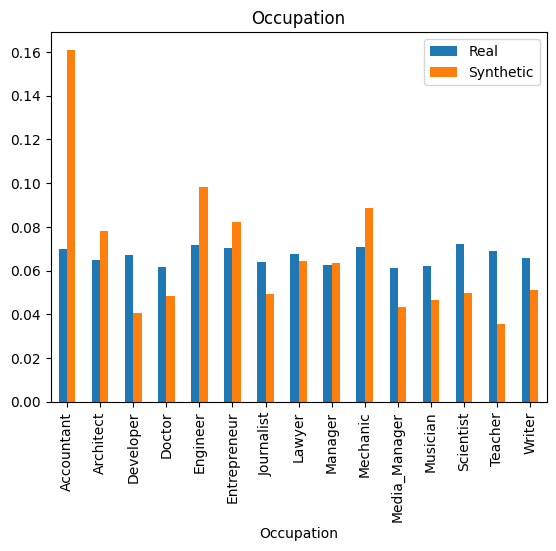


--- Credit_Mix ---
                Real  Synthetic
Credit_Mix                     
Bad         0.497781   0.447775
Standard    0.345470   0.357580
Good        0.156749   0.194645


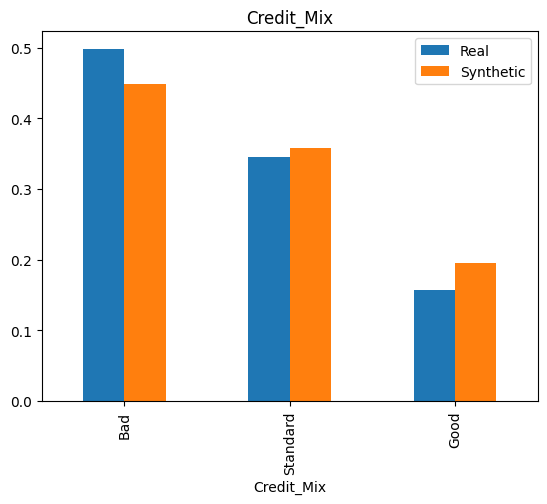


--- Payment_of_Min_Amount ---
                           Real  Synthetic
Payment_of_Min_Amount                     
Yes                    0.722949   0.729553
No                     0.156142   0.191035
NM                     0.120909   0.079411


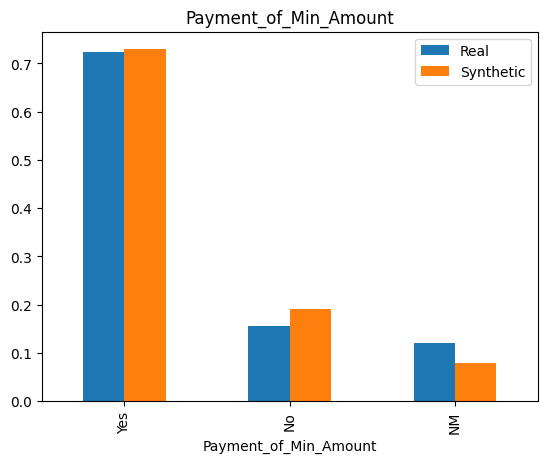


--- Credit_Score ---
              Real  Synthetic
Credit_Score                 
Poor           1.0        1.0


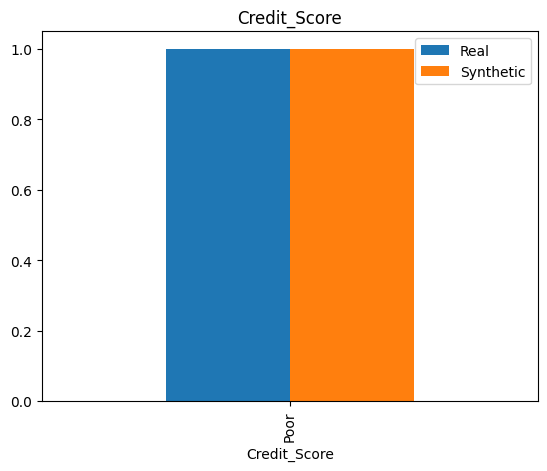


--- Spending_Level ---
                    Real  Synthetic
Spending_Level                     
Low             0.563166    0.60806
High            0.360451    0.29183
Missing         0.076383    0.10011


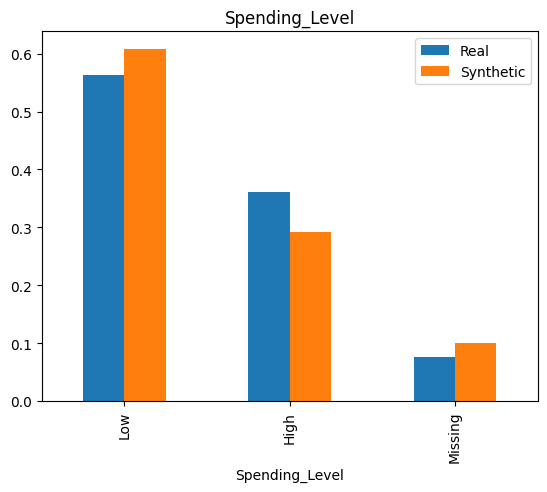


--- Payment_Size ---
                  Real  Synthetic
Payment_Size                     
Small         0.423484   0.530385
Medium        0.298024   0.255963
Large         0.202109   0.119757
Missing       0.076383   0.093896


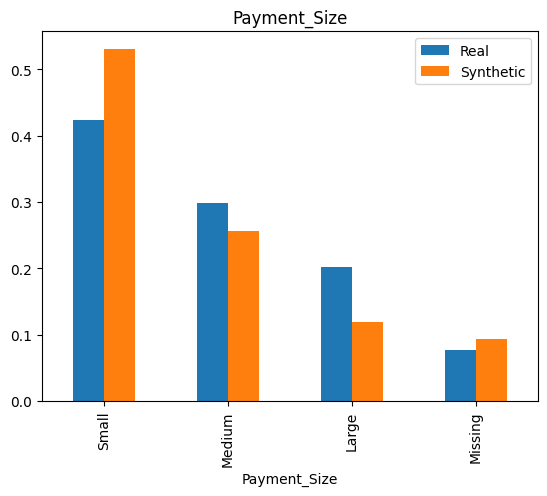

In [15]:
compare_datasets(real=df_poor, synthetic=synthetic_poor, columns=columns)

## a bunch of tables for df standard


NUMERICAL COLUMN ANALYSIS

--- Age ---
Real Mean: 33.36 | Synthetic Mean: 35.95
Real Std:  10.78 | Synthetic Std:  11.27


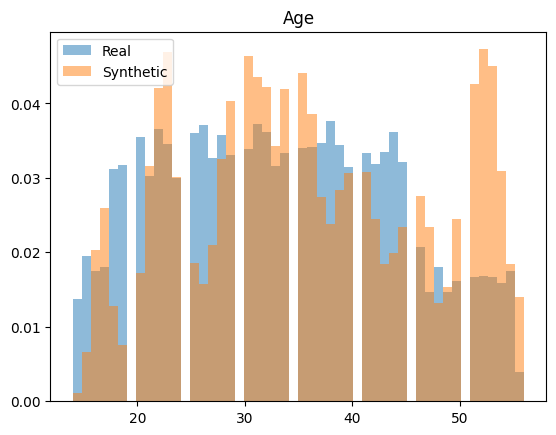


--- Annual_Income ---
Real Mean: 49242.00 | Synthetic Mean: 51734.02
Real Std:  35062.30 | Synthetic Std:  38033.94


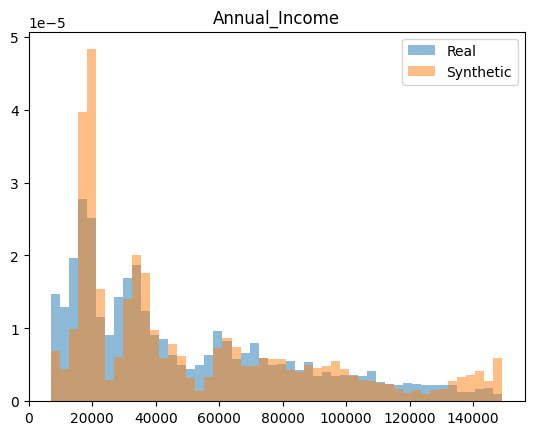


--- Monthly_Inhand_Salary ---
Real Mean: 4093.46 | Synthetic Mean: 4248.46
Real Std:  2919.13 | Synthetic Std:  3141.96


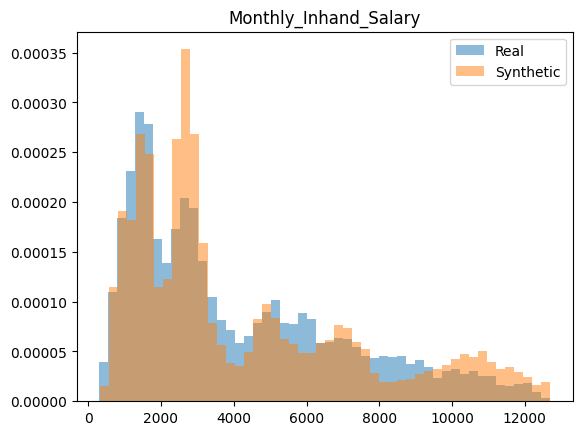


--- Num_Bank_Accounts ---
Real Mean: 5.42 | Synthetic Mean: 5.60
Real Std:  2.35 | Synthetic Std:  2.31


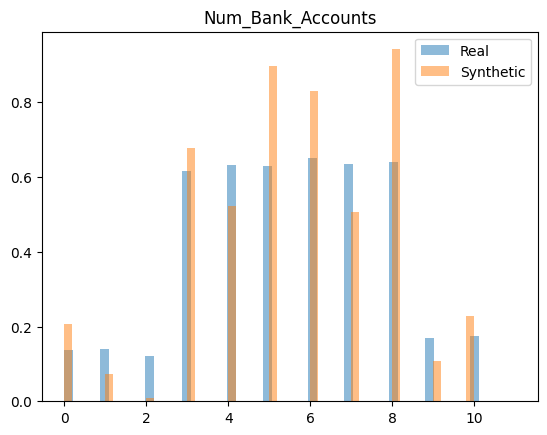


--- Num_Credit_Card ---
Real Mean: 5.42 | Synthetic Mean: 5.72
Real Std:  1.86 | Synthetic Std:  1.78


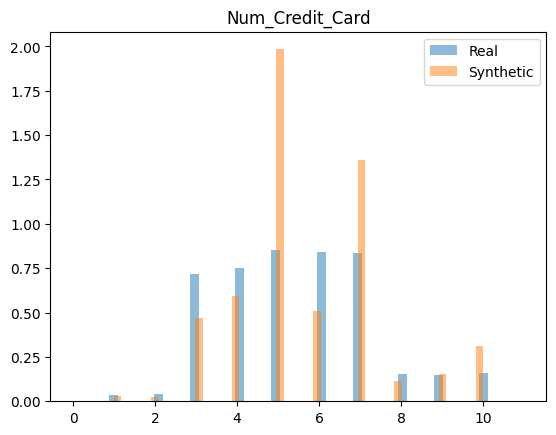


--- Interest_Rate ---
Real Mean: 13.85 | Synthetic Mean: 15.58
Real Std:  7.67 | Synthetic Std:  8.17


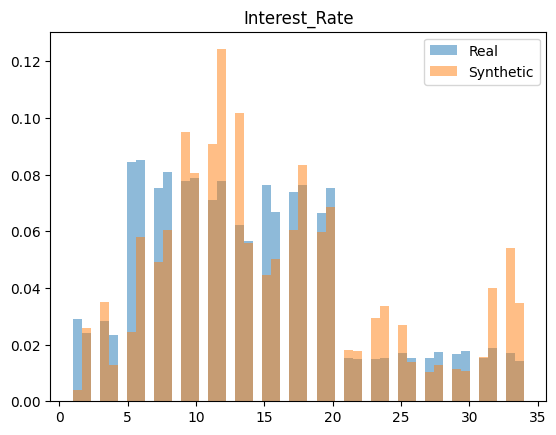


--- Num_of_Loan ---
Real Mean: 3.34 | Synthetic Mean: 3.49
Real Std:  2.38 | Synthetic Std:  2.45


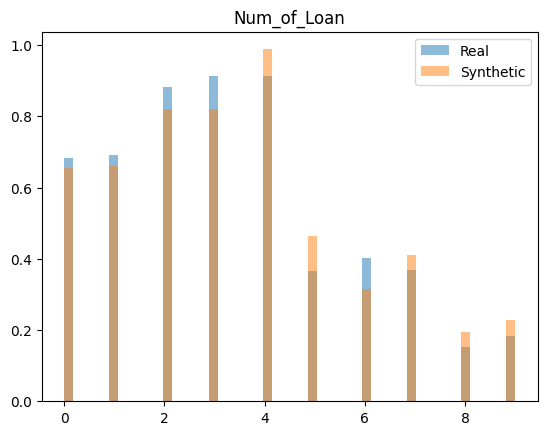


--- Delay_from_due_date ---
Real Mean: 19.93 | Synthetic Mean: 19.44
Real Std:  12.96 | Synthetic Std:  13.32


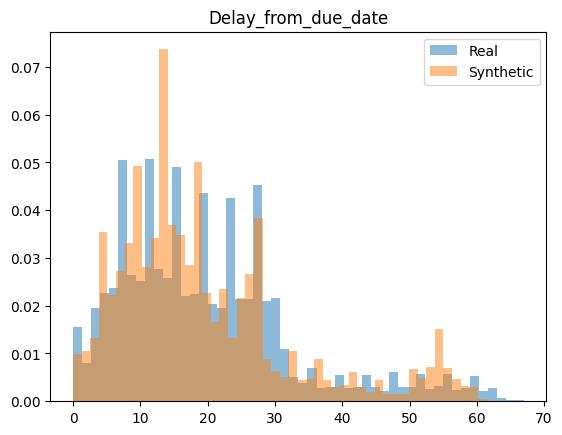


--- Num_of_Delayed_Payment ---
Real Mean: 30.49 | Synthetic Mean: 20.95
Real Std:  220.29 | Synthetic Std:  158.66


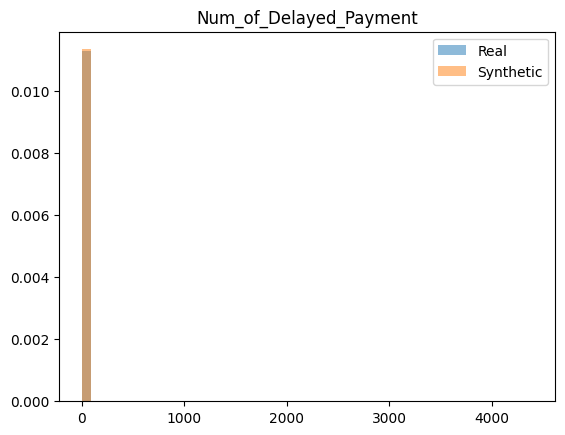


--- Changed_Credit_Limit ---
Real Mean: 11.20 | Synthetic Mean: 11.67
Real Std:  6.51 | Synthetic Std:  7.08


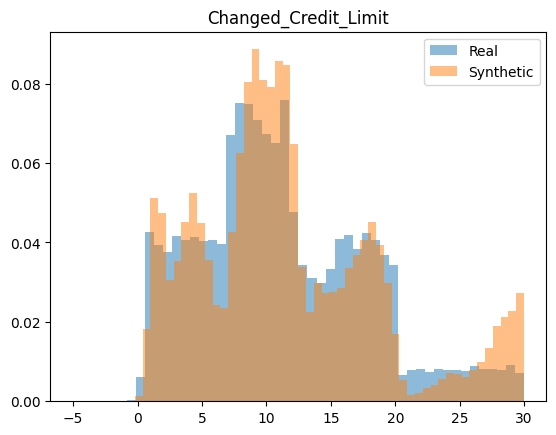


--- Num_Credit_Inquiries ---
Real Mean: 5.29 | Synthetic Mean: 5.58
Real Std:  3.55 | Synthetic Std:  3.59


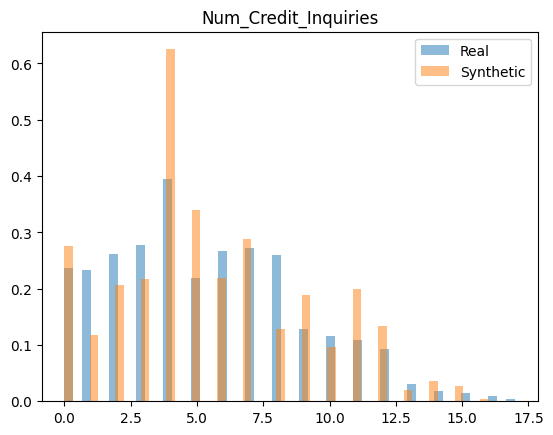


--- Outstanding_Debt ---
Real Mean: 1285.19 | Synthetic Mean: 1259.95
Real Std:  1137.35 | Synthetic Std:  1309.60


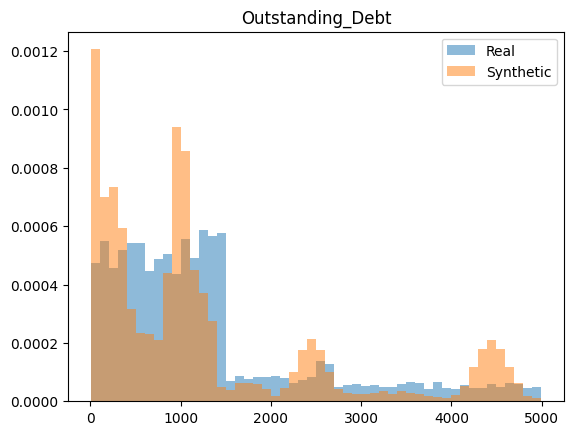


--- Credit_Utilization_Ratio ---
Real Mean: 32.26 | Synthetic Mean: 34.19
Real Std:  5.08 | Synthetic Std:  5.37


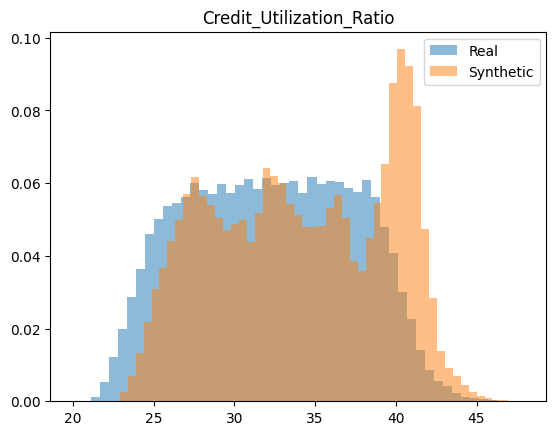


--- Amount_invested_monthly ---
Real Mean: 166.89 | Synthetic Mean: 157.37
Real Std:  114.97 | Synthetic Std:  105.53


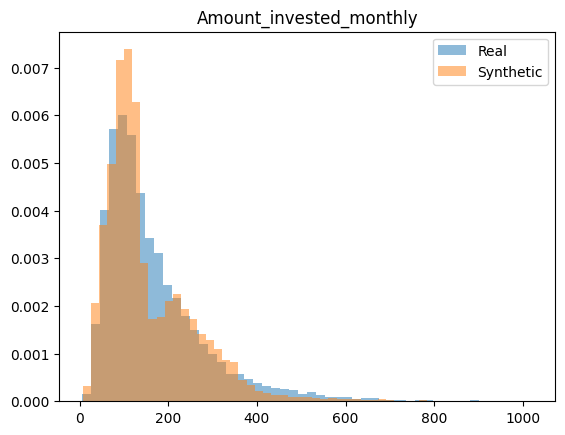


--- Monthly_Balance ---
Real Mean: 401.61 | Synthetic Mean: 444.77
Real Std:  199.12 | Synthetic Std:  208.40


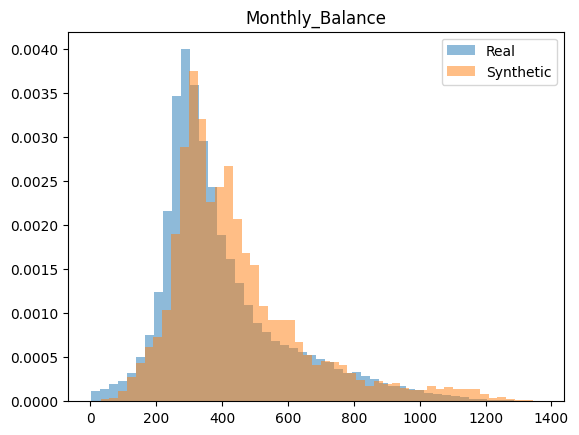


--- Credit_History_Years ---
Real Mean: 18.45 | Synthetic Mean: 18.58
Real Std:  8.30 | Synthetic Std:  9.11


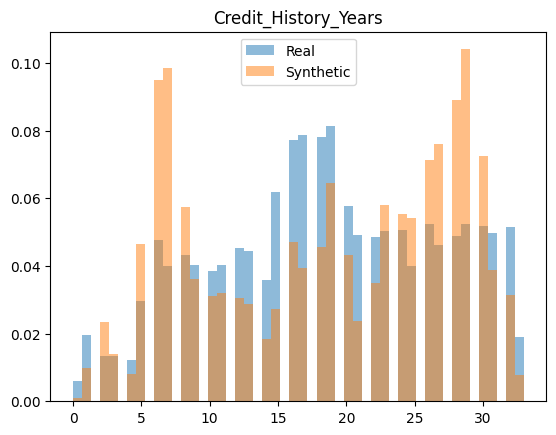


CATEGORICAL COLUMN ANALYSIS

--- Occupation ---
                   Real  Synthetic
Occupation                        
Accountant     0.065530    0.09905
Architect      0.070193    0.04310
Developer      0.067706    0.05065
Doctor         0.067913    0.04115
Engineer       0.065882    0.05520
Entrepreneur   0.064348    0.03060
Journalist     0.064576    0.11980
Lawyer         0.072493    0.10275
Manager        0.063312    0.02815
Mechanic       0.068265    0.04275
Media_Manager  0.069198    0.11065
Musician       0.063934    0.07880
Scientist      0.065903    0.08880
Teacher        0.064245    0.05430
Writer         0.066504    0.05425


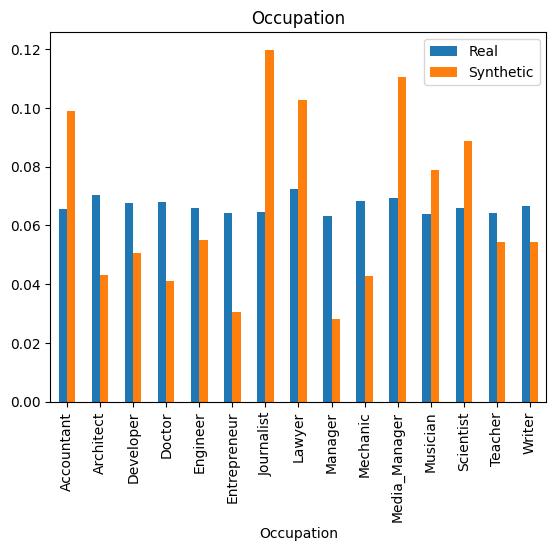


--- Credit_Mix ---
                Real  Synthetic
Credit_Mix                     
Bad         0.173544    0.19915
Good        0.188672    0.15240
Standard    0.637784    0.64845


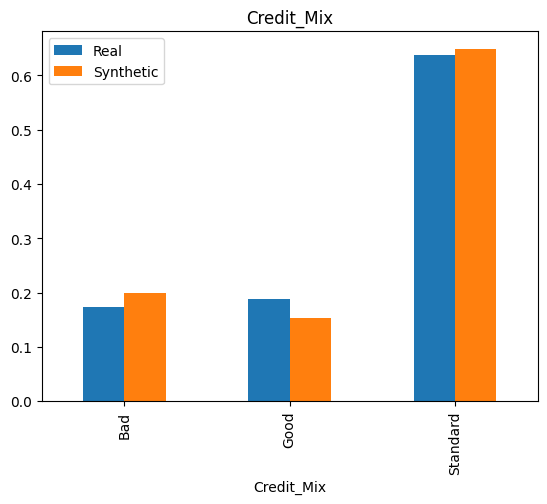


--- Payment_of_Min_Amount ---
                           Real  Synthetic
Payment_of_Min_Amount                     
Yes                    0.566742    0.50510
No                     0.315835    0.29965
NM                     0.117423    0.19525


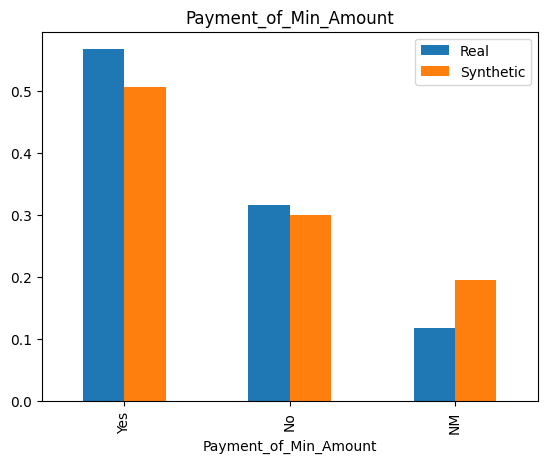


--- Credit_Score ---
              Real  Synthetic
Credit_Score                 
Standard       1.0        1.0


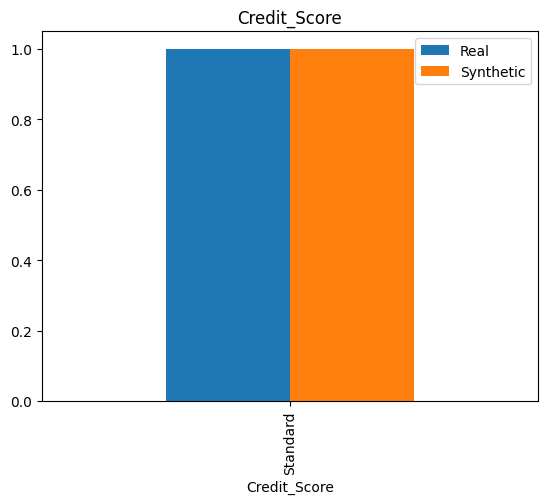


--- Spending_Level ---
                    Real  Synthetic
Spending_Level                     
Low             0.489255    0.55385
High            0.435786    0.35380
Missing         0.074959    0.09235


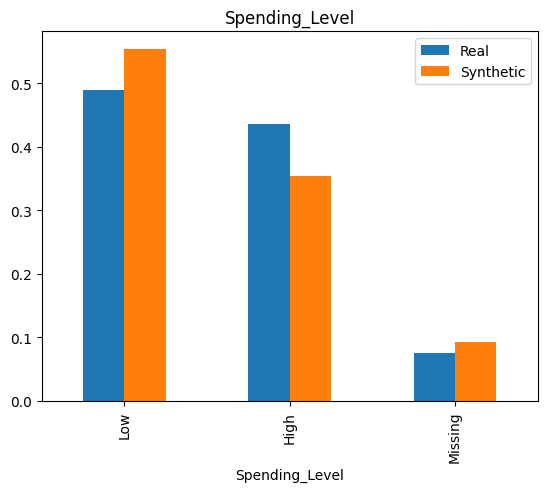


--- Payment_Size ---
                  Real  Synthetic
Payment_Size                     
Small         0.364889    0.43755
Medium        0.313804    0.36495
Large         0.246347    0.11015
Missing       0.074959    0.08735


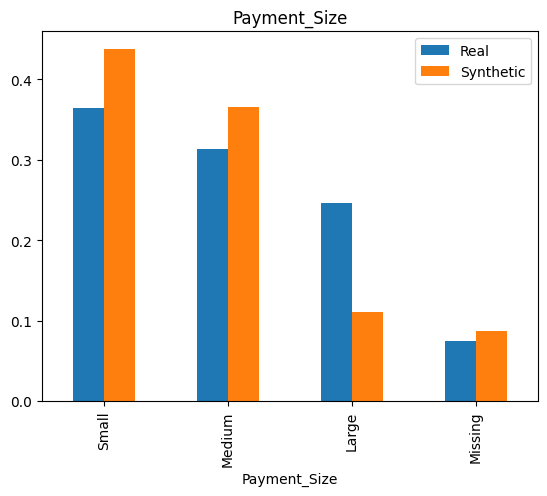

In [16]:
compare_datasets(real=df_standard, synthetic=synthetic_standard_sampled, columns=columns)

## save the models

In [21]:
model_good.save("../models/v2/model_good.pkl")
model_poor.save("../models/v2/model_poor.pkl")
model_standard.save("../models/v2/model_standard.pkl")